# Team: Alexandro Galvez-Vega and Victor Neyra
# Class: CAP 5625-042 Computational Foundations Of AI
# Professor: Michael DeGiorgio

In [29]:
#Starting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

# Deliverables Are Located Below
# __________________________________________________________________
# __________________________________________________________________


In [30]:
#The previous assignment was used as a template
#Similar early logic exists
#Here, we are temporarily turning the csv data into a data frame

filename = "Credit_N400_p9.csv"
advertising_df = pd.read_csv(filename)

#This dataframe is quickly split between the features that will be used for x

x_features_df = advertising_df.copy(deep = True)


#Our goal is to determine credit card balance which is separated into its own df here

y_features_df = x_features_df.pop("Balance") 

In [31]:

#In this part the categorical columns are converted to allow them to be used for the upcoming alogirthms
x_features_df = pd.get_dummies(x_features_df, columns = ["Gender"], drop_first=True, dtype=int)

x_features_df = pd.get_dummies(x_features_df, columns = ["Married"], drop_first=True, dtype=int)

x_features_df = pd.get_dummies(x_features_df, columns = ["Student"], drop_first=True, dtype=int)

In [32]:
#This simply shows that the columns were converted and the original columns are gone
#Earlier the df was place into a deep copy of the original information so the original form exists too
x_features_df.head()

,Income,Limit,Rating,Cards,Age,Education,Gender_Male,Married_Yes,Student_Yes
0,14.891,3606,283,2,34,11,1,1,0
1,106.025,6645,483,3,82,15,0,1,1
2,104.593,7075,514,4,71,11,1,0,0
3,148.924,9504,681,3,36,11,0,0,0
4,55.882,4897,357,2,68,16,1,1,0


In [33]:

#For the purposes of the assignment, we are using ridge regression
#which requires standardization of the data
y_standardized = y_features_df - y_features_df.mean()


##The TA pointed out that encoded features need to be standardized as well
X_standardized = (x_features_df - x_features_df.mean()) / x_features_df.std()





In [34]:
#In the previous assignment a column of 1s was created for Beta 0
#This time it is not necessary
x_standardized_add1 = X_standardized




#This time the starting learning rate is 10 ^ -5
learning_rate_alpha = 10 ** -5

#This is the information of our penalty term lambda
tuning_parameter = 10 ** -2
tuning_parameters_set = [10**-2,10**-1,10**0,10**1,10**2,10**3,10**4,10**5,10**6]
#tuning_parameter = 0


k_fold = 5  

#We get the total number of observations involved
observations_N = len(X_standardized)

#We note the total number of features too
feature_total_p = len(x_standardized_add1.columns)

#The dataframes are converted to numpy arrays to allow for the matrix math that is going to be involved
X = x_standardized_add1.to_numpy()



y = y_standardized.to_numpy()

#This is represents the observation to fold split for the k fold operations
k_N_Splits = observations_N // k_fold 


#Like before, it must be noted that a standardized coefficients are always in a range between -1 and +1"
#Therefore, we use this information again for assignment 2
#Random is once again used to give us a random initial beta, -1 and 1 are used as a range
#This is relevant for the iteration loop that will occur in the later logic of the code

#initial_beta = np.random.uniform(-1, 1, feature_total_p)
initial_beta = np.random.uniform(-1, 1, feature_total_p)


In [35]:
#This is a intermediary holder for the beta information

intermediary_beta = initial_beta

#Vector param beta will act as the final ideal once the loop logic is exited
#This is primariy here to keep the logic easy to follow nd concise

#Placeholder until final values are estbalished
vector_param_beta = initial_beta

#variable to keep track of all beta resuls for graphing
record_of_v_beta = []


#variable to keep track of the cost history for graphing
record_of_cost = []

#The iteration loop size is set to 100,000 this time around

iter_loops = 1_000

b_k_set = np.sum(X**2)
beta_loop_length = len(intermediary_beta)

In [36]:
def tuning_cv_loop_elastic(elastic_tp):
    #This wil hold all the cv error and beta scores 
    cross_validation_account_final = []
    vector_parameter_beta_final = []

    cross_validation_beta_account_final = []
    #This loop is to go through each penalty value
    for current_tuning_paremeter in tuning_parameters_set:
        #This is the current penalty term
        tuning_parameter = current_tuning_paremeter
        #The observations are randomly reorganized
        random_reorder = np.random.permutation(observations_N)
        #This will track the immedia cv errors as we parse through each fold in the 5 k old operation
        cross_validation_account = []
        #This will hold beta
        cross_validation_beta_account = []
        
        #This is to loop through all the folds with the current penalty value in place
        for fold in range(k_fold):
            
            #This is a reset for the beta for each iteration
            intermediary_beta = initial_beta.copy()

            #This logic is for observation placement after the random reorganization
            #A section of the observations is taken based on the current fold in play and the split size
            beg_index = fold * k_N_Splits
            end_index = (fold + 1) * k_N_Splits
            beg_to_end_indexes = np.arange(beg_index, end_index)


            #The observations for the validation part of the cross validation loop are set in place here
            validation_unit = random_reorder[beg_to_end_indexes]
            X_validation_set = X[validation_unit]
            y_validation_set = y[validation_unit]
            
            #The observations for the training part of the cross validation loop are set in place here
            X_training_set = np.delete(X, validation_unit, axis=0)
            y_training_set = np.delete(y, validation_unit, axis=0)

            
            #This loop exists for the batch gradient descent logic
            for iter_c in range(iter_loops):

                X_training_transposed = np.transpose(X_training_set)

                for k_current in range(beta_loop_length):
                    X_k_current = X_training_set[:,k_current]
                    a_k_p1 = y_training_set - X_training_set.dot(intermediary_beta) 
                    a_k_p2 = a_k_p1 + (X_k_current * intermediary_beta[k_current])
                    a_k_set = X_training_transposed[k_current].dot(a_k_p2)
                    

                    if a_k_set < - ((current_tuning_paremeter) * (1-elastic_tp)) / 2:
                        intermediary_beta[k_current] = (a_k_set + ((current_tuning_paremeter * (1 - elastic_tp))/2))/ (b_k_set + (current_tuning_paremeter * elastic_tp))
                    elif a_k_set > ((current_tuning_paremeter) * (1-elastic_tp)) / 2:
                        intermediary_beta[k_current] = (a_k_set - ((current_tuning_paremeter * (1 - elastic_tp))/2))/ (b_k_set + (current_tuning_paremeter * elastic_tp))
                    else:
                        intermediary_beta[k_current] = 0

                # #X transposed is set for future equation use
                # X_training_transposed = np.transpose(X_training_set)
                
                # #The equation from assignment 2 is chunked out between the next three lines of code
                # #to adjust the beta values, one small difference include in terms of arrangement
                # update_pv_p1 = X_training_transposed.dot(y_training_set - X_training_set.dot(intermediary_beta))

                
                # update_pv_p2 = (update_pv_p1 - (tuning_parameter * intermediary_beta))
                # intermediary_beta += 2 * learning_rate_alpha * update_pv_p2
            
            #Outside of the loop the y output is predicted based on the validation set and beta provided
            y_vaidation__set_predicted = X_validation_set.dot(intermediary_beta)
            
            #a validation error score is marked based on the information
        
            validation_error = np.sum((y_validation_set - y_vaidation__set_predicted)**2) / len(y_validation_set)
            
            #The information is appended for future use
            cross_validation_account.append(validation_error)
            
            cross_validation_beta_account.append(intermediary_beta)
            #print(validation_error)
        #After the cross validation loop is done the cv error is achieved by getting the mean
        cross_validation_error = np.mean(cross_validation_account)
        #The cv error from using the current penalty value is appended to find the lowest cross validation score later
        cross_validation_account_final.append(cross_validation_error)
        #Beta is marked too
        vector_parameter_beta_final.append(intermediary_beta)
        #The mean beta from the cv loop is marked too
        cross_validation_beta_account_final.append(np.mean(cross_validation_beta_account, axis=0))
        #print(cross_validation_error)
    print(cross_validation_account_final)

    return cross_validation_account_final, vector_parameter_beta_final, cross_validation_beta_account_final










In [37]:
elastic_tuning_parameter_set = [0, .2, .4, .6, .8,  1]
cross_validation_account_final=[]
vector_parameter_beta_final=[]
cross_validation_beta_account_final=[]

etp_cross_validation_account_final = []
etp_vector_parameter_beta_final = []
etp_cross_validation_beta_account_final = []
for elastic_tuning_parameter in elastic_tuning_parameter_set:
    elastic_tp = elastic_tuning_parameter
    cross_validation_account_final, vector_parameter_beta_final, cross_validation_beta_account_final = tuning_cv_loop_elastic(elastic_tp)
    etp_cross_validation_account_final.append(cross_validation_account_final)
    etp_vector_parameter_beta_final.append(vector_parameter_beta_final)
    etp_cross_validation_beta_account_final.append(cross_validation_beta_account_final)


[158752.7986142776, 158983.08498532537, 159279.0519651415, 158526.85089850353, 159003.8491950631, 158886.79487295076, 160723.9134150947, 181355.58707242872, 210849.779775]
[158577.38760876798, 158729.0001997446, 158614.32165087442, 158509.34491551257, 158706.81938879826, 161269.79048601203, 175638.8672670163, 204782.91277221896, 210849.779775]
[158541.9400403131, 158275.99515004514, 158693.1747985358, 158716.06438616593, 159239.79111883693, 163681.48448989805, 183865.43520649266, 207054.01518413363, 210849.77977500003]
[158339.0477559797, 158919.9699131108, 158736.67771726538, 158620.8416961475, 158906.9236728932, 164945.2148593901, 188945.0432650904, 207886.01008750134, 210849.779775]
[158832.84373689746, 158731.55379159833, 159117.0989954583, 158648.1580990642, 159309.31782225106, 166669.01680280332, 192056.77836858886, 208307.14225641725, 210797.6609748405]
[158406.14014797285, 158426.7569568014, 158378.10811526675, 158659.6852674033, 159638.08178240125, 167811.10354973353, 194529.9

In [38]:
print(etp_vector_parameter_beta_final[0])

[array([15.99086368, 32.77698742, 32.9826093 ,  3.45667539, -0.19273301,
        0.70046223,  0.92841631, -0.87305726, 11.08406436]), array([ 1.48958096e+01,  3.16534210e+01,  3.16783117e+01,  3.43472797e+00,
       -5.87411287e-01, -1.48675139e+00,  3.03022637e-02,  2.93425688e-01,
        1.10224562e+01]), array([12.01874689, 28.74216516, 28.51989439, -0.18190022, -0.55606883,
       -1.4338826 ,  0.18959674, -0.20407559,  9.58205027]), array([15.17203954, 32.36777135, 32.53080923,  3.58825148, -1.28255075,
       -0.96950717, -1.27589836, -1.40441242, 11.10729232]), array([11.60529616, 29.55908035, 29.50810867,  1.36316597,  0.49907112,
        0.92384717, -0.44564072, -1.886754  , 11.65974818]), array([13.88419109, 30.74906252, 30.77129242,  3.56223978,  0.19741428,
        0.91636099, -1.19193447,  0.67495722, 12.45453623]), array([12.93931373, 29.88301466, 30.0351498 ,  1.77035467, -0.49732085,
        0.77837822,  0.        ,  0.        ,  9.81304169]), array([ 0.        , 16.86

In [39]:
print(etp_vector_parameter_beta_final[1])

[array([ 1.48252693e+01,  3.21722307e+01,  3.22445594e+01,  3.44703110e+00,
       -1.34289712e-01, -5.81978420e-01,  5.37242752e-01,  2.27810984e-02,
        1.09553087e+01]), array([15.72306104, 32.66901104, 32.83535039,  2.8012833 , -0.99950768,
        0.88173691, -0.87857038, -0.96115529, 10.69607473]), array([15.31280146, 31.54027691, 31.57975867,  3.23038358, -1.39559975,
       -0.6345305 , -3.16809383,  1.17451116, 10.57130596]), array([15.38268904, 32.30396808, 32.34711822,  2.87544724, -3.06742177,
        0.03885179, -1.20595955, -0.26461212,  9.64927165]), array([12.94515617, 30.11673055, 30.25046881,  3.47646526, -2.81585458,
        0.06048405, -0.70383632,  0.69702857, 10.29846682]), array([14.27366484, 30.41799089, 30.60552364,  4.94121752,  0.62475823,
        0.53103164, -0.67973373, -0.80773671, 11.1427531 ]), array([10.05528139, 20.73992922, 20.76859238,  1.64885839,  0.        ,
        0.        ,  0.        ,  0.        ,  5.72970342]), array([1.02301133, 3.3585

In [40]:
print(etp_vector_parameter_beta_final[2])

[array([14.34476648, 31.90731475, 32.04986675,  4.05516703,  0.2921209 ,
       -0.46848509, -1.33478196, -0.53250753, 10.15278947]), array([15.1864956 , 31.9880061 , 32.12512343,  3.67978683, -1.18902984,
       -0.55452899, -1.14428633,  0.39762221,  9.51010798]), array([ 1.26540579e+01,  2.93436308e+01,  2.94513272e+01,  2.54540791e+00,
       -8.63139813e-01, -1.06203301e-02, -2.56810822e+00, -7.22784102e-01,
        1.02763805e+01]), array([15.35519438, 32.80945337, 32.86100178,  4.84642234, -0.83586615,
        0.39652928,  0.48250345,  0.58565063, 10.41798354]), array([15.84230552, 32.8017313 , 32.75695642,  3.56764374,  0.12112221,
        0.16233147, -1.04412528, -0.37975189,  9.36459443]), array([12.14128762, 27.09100335, 27.11772187,  2.34403519,  0.99883255,
        1.18764368, -1.15531574,  0.77599273, 10.00824756]), array([ 7.70791646, 15.3937818 , 15.44366736,  2.203197  ,  0.        ,
        0.        ,  0.        , -0.17871963,  4.48100819]), array([0.67075565, 2.0180

# __________________________________________________________________
# __________________________________________________________________

In [41]:
print(tuning_parameters_set)

[0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]


In [42]:
def coeffecientsvptp(current_vector_param_b, graph_title):
    
    current_vector_param_b = np.array(current_vector_param_b)
    
    tp_log_set = [-2,-1,0,1,2,3,4,5,6]

    plt.figure(figsize=(10, 6))

    #Using the beta values found at each penalty parameter a graph is made. Labels show a beta for each specific column
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,0], label="Income")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,1], label="Limit")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,2], label="Rating")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,3], label="Cards")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,4], label="Education")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,5], label="Gender")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,6], label="Married")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,7], label="Student")
    plt.xticks(ticks=tuning_parameters_set, labels=tp_log_set)
    plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
    plt.ylabel('Coefficient Values')
    #plt.title('Standardized Coefficients Against Penalty Tuning Parameters')
    plt.title(graph_title)
    plt.legend(loc=1)
    plt.show()

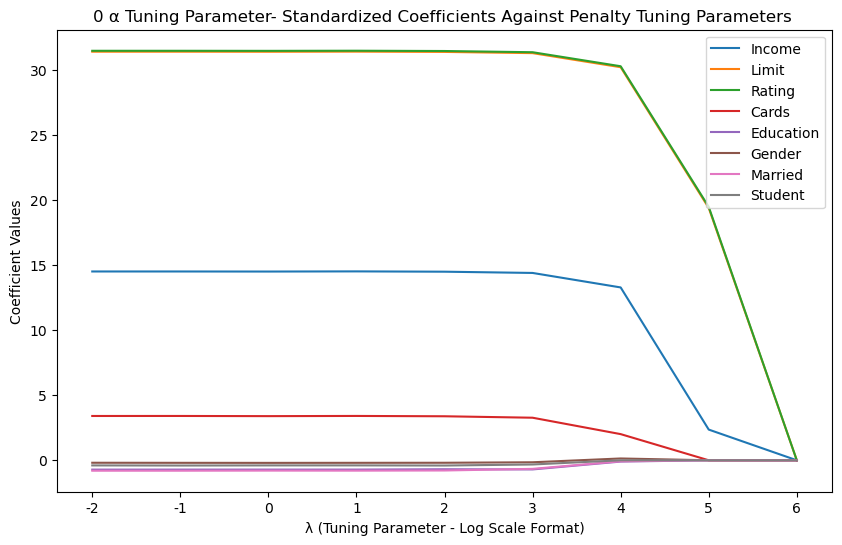

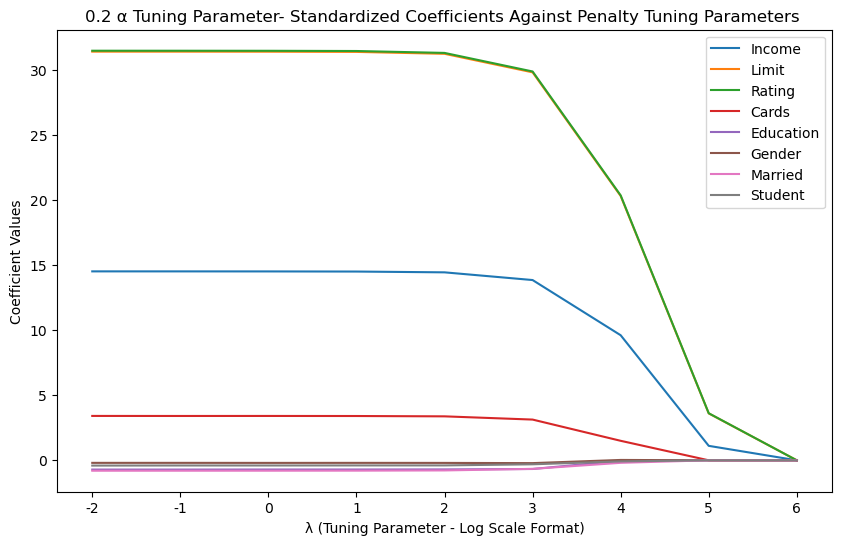

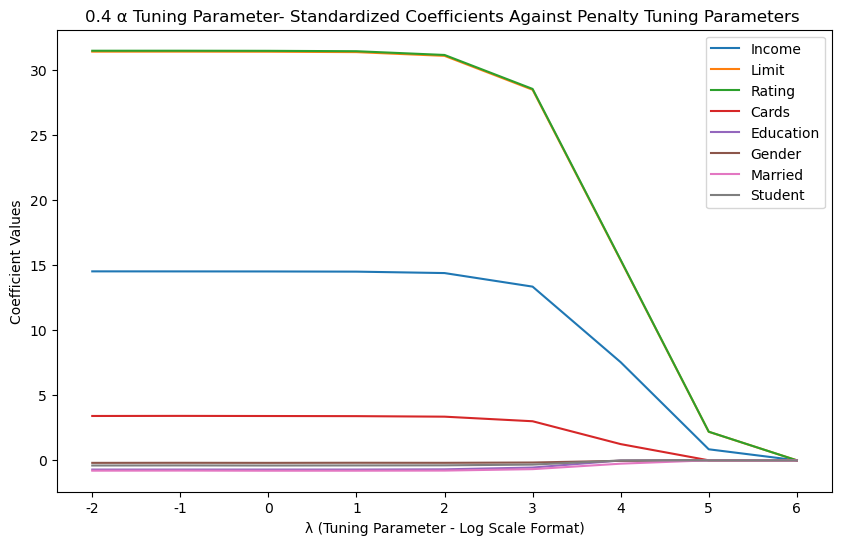

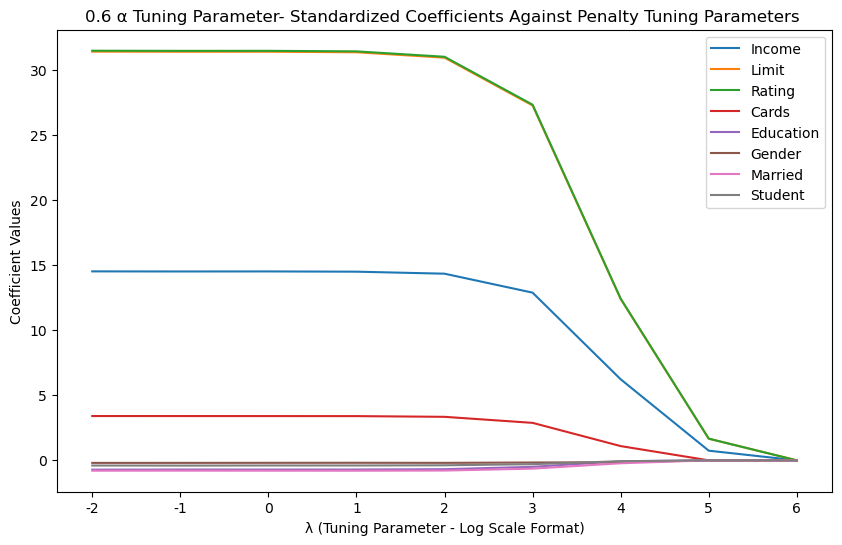

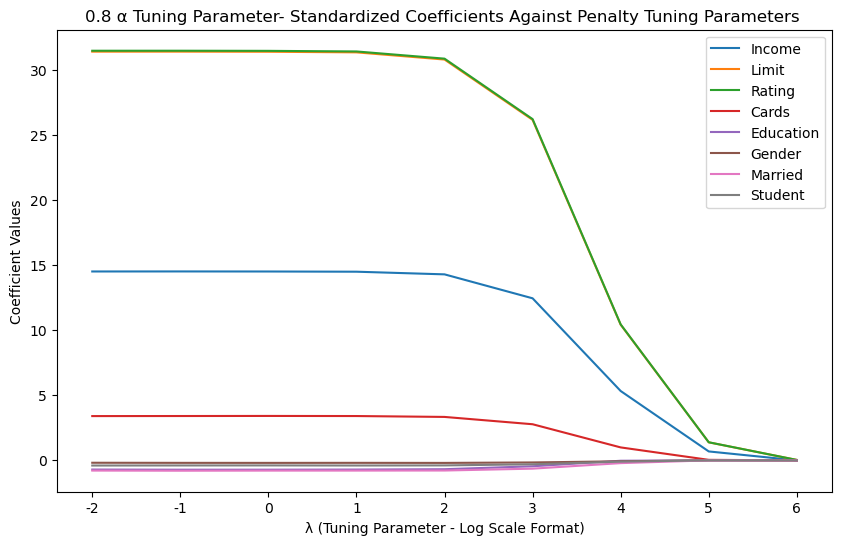

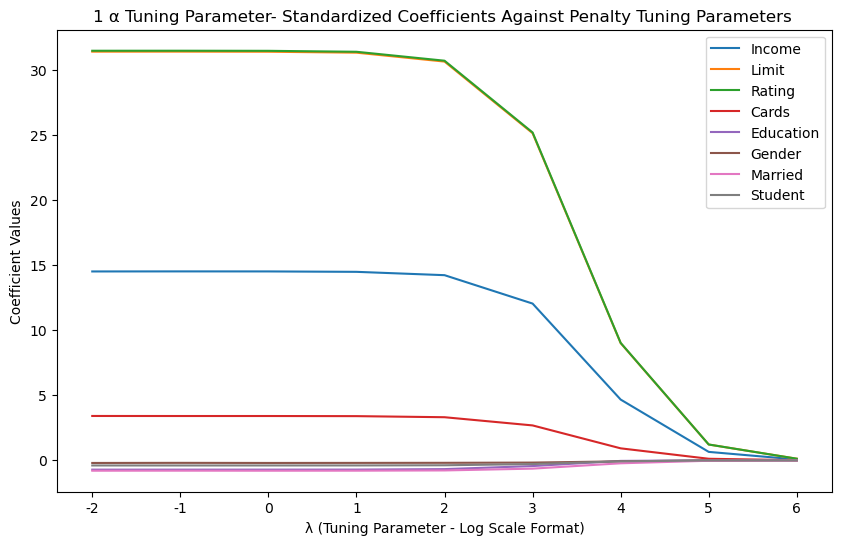

In [43]:
for current_graph_etp in range(len(elastic_tuning_parameter_set)):
    current_vector_param_b = etp_cross_validation_beta_account_final[current_graph_etp]
    
    graph_title = str(elastic_tuning_parameter_set[current_graph_etp]) + " α Tuning Parameter- Standardized Coefficients Against Penalty Tuning Parameters "
    coeffecientsvptp(current_vector_param_b,  graph_title)
    

# __________________________________________________________________
# __________________________________________________________________

In [44]:
#Getting image
image_load = "a2dev2.png"

# # Display the image
Image(filename=image_load) 

FileNotFoundError: [Errno 2] No such file or directory: 'a2dev2.png'

In [45]:
def errorvpenaltyperetp(cv_account_current, graph_title):
    tp_log_set = [-2,-1,0,1,2,3,4,5,6]
    #This graph shows the cross validation error scores across all of the penalty terms
    plt.figure(figsize=(10, 6))
    plt.semilogx(tuning_parameters_set, cv_account_current, 'bo-')
    plt.xticks(ticks=tuning_parameters_set, labels=tp_log_set)
    plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
    plt.ylabel('Cross-Validation Error Scores')
    #plt.title('Cross-Validation Error Scores Against Penalty Parameters')
    plt.title(graph_title)
    plt.show()

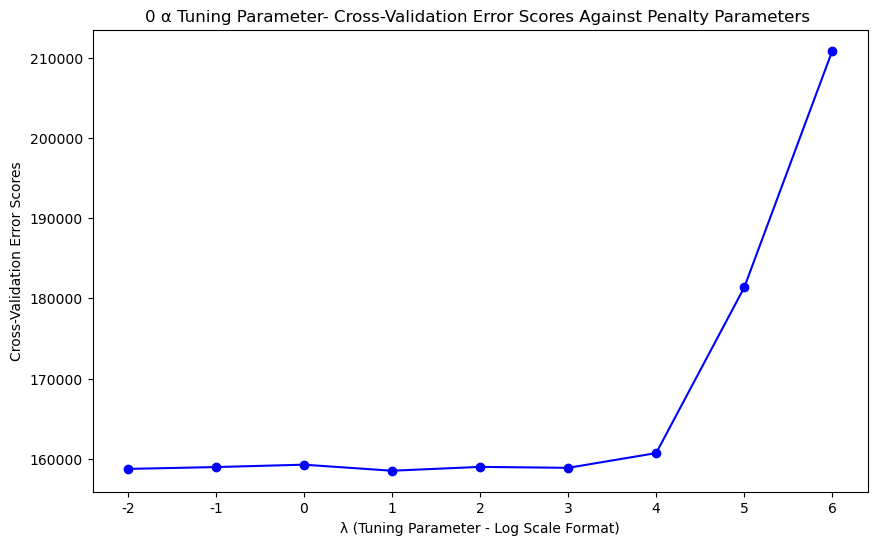

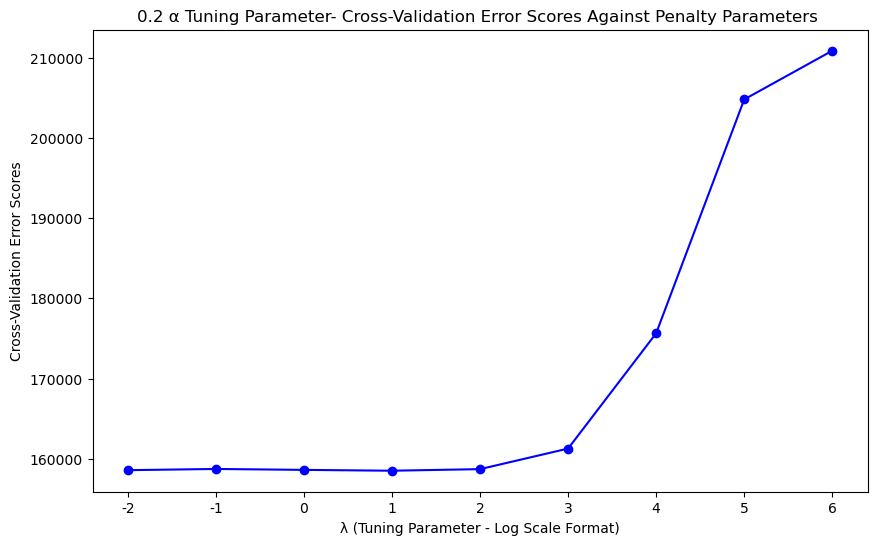

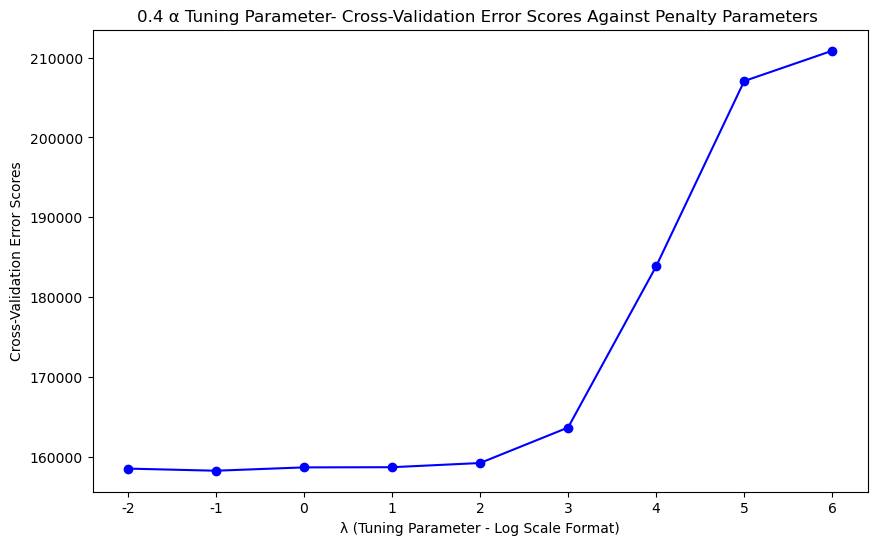

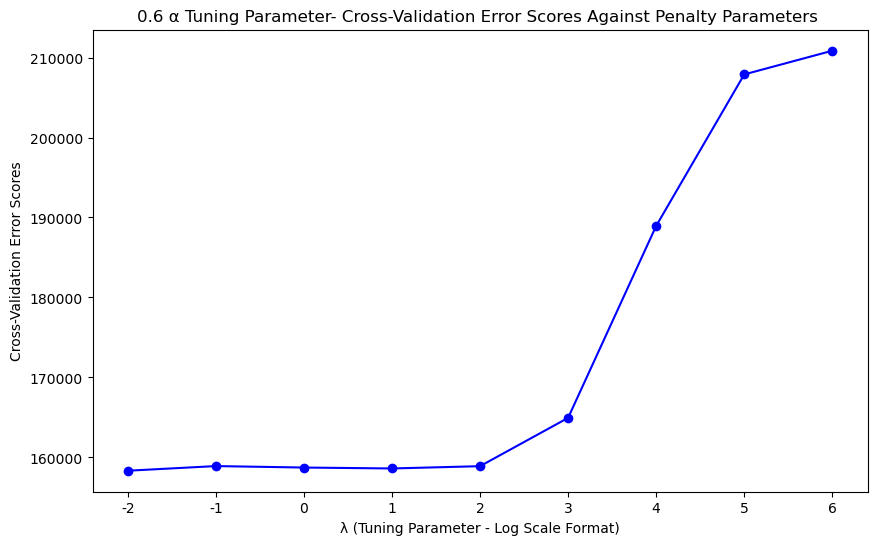

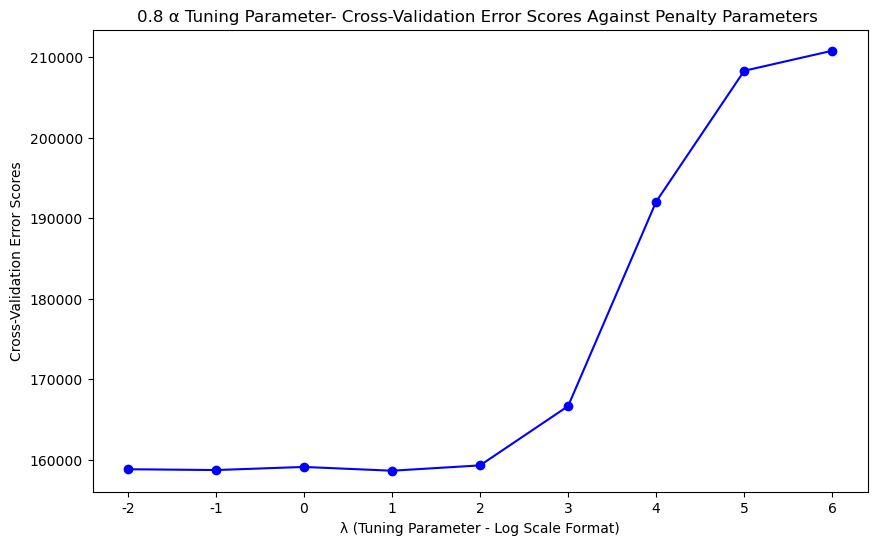

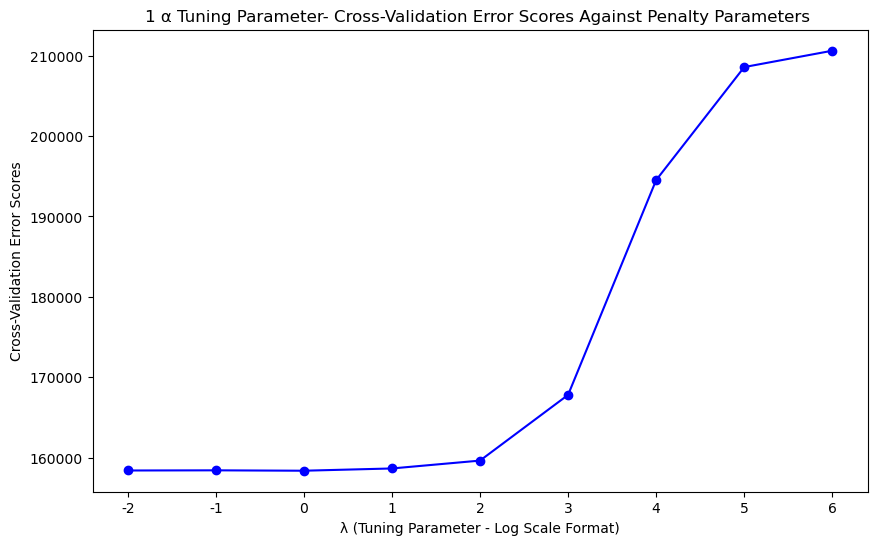

In [46]:
for current_graph_etp in range(len(elastic_tuning_parameter_set)):
    current_vector_param_b = etp_cross_validation_account_final[current_graph_etp]
    
    graph_title = str(elastic_tuning_parameter_set[current_graph_etp]) + " α Tuning Parameter- Cross-Validation Error Scores Against Penalty Parameters "
    errorvpenaltyperetp(current_vector_param_b,  graph_title)

# __________________________________________________________________
# __________________________________________________________________

In [51]:
lowest_cross_validation_errors = []
placeholder_cve = min(etp_cross_validation_account_final[0])


In [52]:
placerholder_etp_position = 0

In [56]:
                 
for current_etp in range(len(elastic_tuning_parameter_set)):
    lowest_cross_validation_error = min(etp_cross_validation_account_final[current_etp])
    if lowest_cross_validation_error < placeholder_cve:
                      placeholder_cve = lowest_cross_validation_error
                      placerholder_etp_position = current_etp
print("The lowest cross-validation error score achieved: " + str(placeholder_cve))
print("Alpha tuning parameter used " + str(elastic_tuning_parameter_set[placerholder_etp_position]))

The lowest cross-validation error score achieved: 158275.99515004514
Alpha tuning parameter used 0.4


In [57]:
#This lowest cross validation error score is used to get the the lambda parameter used to achieve this score
tuning_parameter_lowest_cv = 0

cva_final = etp_cross_validation_account_final[placerholder_etp_position]
for i in range(len(cva_final)):
    if cva_final[i] == placeholder_cve:
        tuning_parameter_lowest_cv = tuning_parameters_set[i]

print("The lambda parameter that resulted in the lowest cross-validation score: " + str(tuning_parameter_lowest_cv))
#print(tuning_parameter_lowest_cv)


The lambda parameter that resulted in the lowest cross-validation score: 0.1


# __________________________________________________________________
# __________________________________________________________________

In [ ]:
#Getting image
image_load = "a2dev4.png"

# # Display the image
Image(filename=image_load) 

In [ ]:
#This is a simpler version of the earlier code without the penalty parameter loop of the k fold loop now that an
#optimal lambda value has been discovered
#all of the observations are used for a final y prediction
#The mse and final beta is found too
cross_validation_account_final = []
vector_parameter_beta_final = []

cross_validation_beta_account_final = []


tuning_parameter = tuning_parameter_lowest_cv
random_reorder = np.random.permutation(observations_N)
intermediary_beta = initial_beta.copy()
X_final = X[random_reorder]
y_final = y[random_reorder]

for iter_c in range(iter_loops):
        #lkmlkml
        X_final_transposed = np.transpose(X_final)
        #The math here can be found from a1
        update_pv_p1 = X_final_transposed.dot(y_final - X_final.dot(intermediary_beta))
        #update_pv_p2 = ((tuning_parameter * intermediary_beta) - update_pv_p1)
        update_pv_p2 = (update_pv_p1 - (tuning_parameter * intermediary_beta))
        intermediary_beta += 2 * learning_rate_alpha * update_pv_p2

y_final_predicted = X_final.dot(intermediary_beta)
mean_squared_error = np.sum((y_final - y_final_predicted)**2) / len(y_final)
final_vector_param_beta = intermediary_beta


In [ ]:
#This prints out the beta parameters based on the model that used all the observation data
#The values are rounded to the fourth decimal point
print("9 Best Fit Model Parameters Based On Tuning Parameter That Produced The Lowest Cross-Validation Error Score: ")
#Income	Limit	Rating	Cards	Age	Education	Gender_Male	Married_Yes	Student_Yes


print("Income: " + str(round(final_vector_param_beta[0], 4)))
print("Limit: " + str(round(final_vector_param_beta[1], 4)))
print("Rating: " + str(round(final_vector_param_beta[2], 4)))
print("Cards: " + str(round(final_vector_param_beta[3], 4)))
print("Age: " + str(round(final_vector_param_beta[4], 4)))
print("Education: " + str(round(final_vector_param_beta[5], 4)))
print("Gender: " + str(round(final_vector_param_beta[6], 4)))
print("Married: " + str(round(final_vector_param_beta[7], 4)))
print("Student: " + str(round(final_vector_param_beta[8], 4)))


In [ ]:
# __________________________________________________________________
# __________________________________________________________________